# Project 2 — Dataset Exploration: Nuclei


In [19]:
!pip install scikit-learn


## 1. Libraries and static var defs


In [20]:
import json
from pathlib import Path
import numpy as np             
import matplotlib.pyplot as plt
import cv2                                     

#Figure Plotting Settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

# Path Settings — this notebook lives inside Task2/, so go up one level for shared data
PROJECT_ROOT  = Path("..")
DATASET_ROOT  = PROJECT_ROOT / "Dataset_Splits"
PREPARED_DIR  = Path(".") / "task2_dataset"
TEST_SET_DIR  = PROJECT_ROOT / "Task2_Test_Set"

SPLITS = ["train", "validation", "test"]


## 2. Exploring the Dataset

In [21]:
# Exploring Dataset

for split in SPLITS:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists():
        print(f"Error")
    img_count   = len(list((split_dir / "image").glob("*.tif")))
    nuclei_count = len(list((split_dir / "nuclei").glob("*.geojson")))
    print(f"\n{split}")
    print(f"images: {img_count}")
    print(f"nuclei: {nuclei_count}")

print("\nTask2 Test Set:")
npy_files = sorted(TEST_SET_DIR.glob("*.npy"))
print(f"{len(npy_files)}")


train
images: 163
nuclei: 163

validation
images: 20
nuclei: 20

test
images: 22
nuclei: 22

Task2 Test Set:
1858


In [22]:
# Exploring GeoJSON File
sample_geojson = DATASET_ROOT / "train" / "nuclei" / "training_set_metastatic_roi_001_nuclei.geojson"

with open(sample_geojson) as f:
    gj = json.load(f)

features_gj = gj["features"][0]
print(list(gj.keys()))
print("Features:", list(features_gj.keys()))
print("Id:", features_gj["id"])
print("properties:", features_gj["properties"])
print("geometry:", features_gj["geometry"]["type"])
print("no of points:", len(features_gj["geometry"]["coordinates"][0]))
print(f"total objects: {len(gj['features'])}")

['type', 'features']
Features: ['type', 'id', 'geometry', 'properties']
Id: 77797017-2159-4289-be43-1c6ad5e07780
properties: {'objectType': 'annotation', 'classification': {'name': 'nuclei_tumor', 'color': [200, 0, 0]}}
geometry: Polygon
no of points: 80
total objects: 633


In [23]:
# Finding all nuclei classes
classes_nuclei = set()
no_classes_per_split = {s: {} for s in SPLITS}

for split in SPLITS:
    nuclei_dir = DATASET_ROOT / split / "nuclei"
    for gj_path in nuclei_dir.glob("*.geojson"):
        with open(gj_path) as f:
            data = json.load(f)
        for features_gj in data.get("features", []):
            cls = features_gj.get("properties", {}).get("classification", {}).get("name")
            if cls:
                classes_nuclei.add(cls)
                no_classes_per_split[split][cls] = no_classes_per_split[split].get(cls, 0) + 1

nuclei_classes = sorted(c for c in classes_nuclei if c.startswith("nuclei_"))

print("Nuclei classes found:", nuclei_classes)
print(f"\nTotal classes: {len(nuclei_classes)}")

Nuclei classes found: ['nuclei_apoptosis', 'nuclei_endothelium', 'nuclei_epithelium', 'nuclei_histiocyte', 'nuclei_lymphocyte', 'nuclei_melanophage', 'nuclei_neutrophil', 'nuclei_plasma_cell', 'nuclei_stroma', 'nuclei_tumor']

Total classes: 10



## 3. Checking Image

In [24]:
X_train = np.load(PREPARED_DIR / "X_train.npy")
y_names_train = np.load(PREPARED_DIR / "y_names_train.npy", allow_pickle=True)

print(f"X_train shape : {X_train.shape}   dtype: {X_train.dtype}")
print(f"y_names_train : {y_names_train.shape}  unique classes: {np.unique(y_names_train)}")

with open(PREPARED_DIR / "class_names.json") as f:
    idx_to_class = json.load(f)

class_to_idx = {v: int(k) for k, v in idx_to_class.items()}
ORDERED_CLASSES = [idx_to_class[str(i)] for i in range(len(idx_to_class))]
#Classes Indexed
for idx, name in idx_to_class.items():
    print(f"  {idx}: {name}")

X_train shape : (76069, 100, 100, 3)   dtype: uint8
y_names_train : (76069,)  unique classes: ['nuclei_apoptosis' 'nuclei_endothelium' 'nuclei_epithelium'
 'nuclei_histiocyte' 'nuclei_lymphocyte' 'nuclei_melanophage'
 'nuclei_neutrophil' 'nuclei_plasma_cell' 'nuclei_stroma' 'nuclei_tumor']
  0: nuclei_apoptosis
  1: nuclei_endothelium
  2: nuclei_epithelium
  3: nuclei_histiocyte
  4: nuclei_lymphocyte
  5: nuclei_melanophage
  6: nuclei_neutrophil
  7: nuclei_plasma_cell
  8: nuclei_stroma
  9: nuclei_tumor


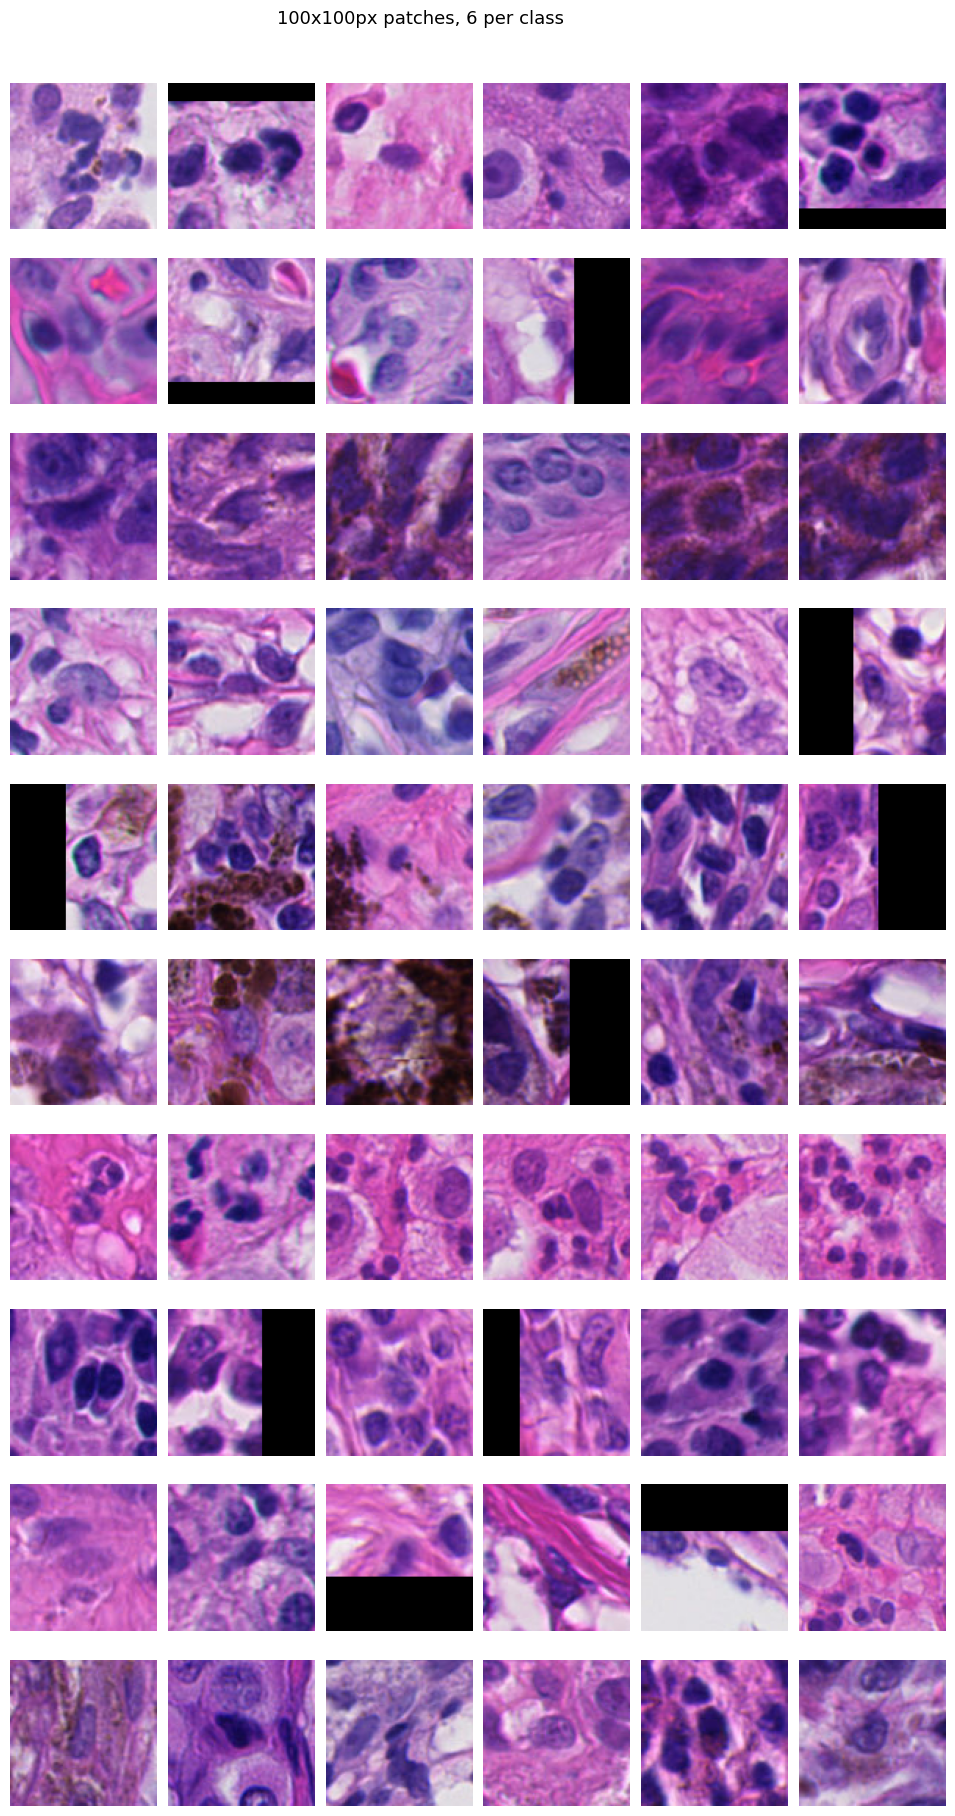

In [25]:
np.random.seed(42)

N_COLS = 6
fig, axes = plt.subplots(len(ORDERED_CLASSES), N_COLS, figsize=(N_COLS * 1.8, len(ORDERED_CLASSES) * 1.8))
fig.suptitle("100x100px patches, 6 per class", fontsize=13, y=1.01)

for row, cls in enumerate(ORDERED_CLASSES):
    idx_all = np.where(y_names_train == cls)[0]
    picks = np.random.choice(idx_all, size=N_COLS, replace=len(idx_all) < N_COLS)
    for col, pick in enumerate(picks):
        ax = axes[row, col]
        ax.imshow(X_train[pick])
        ax.axis("off")
        if col == 0:
            short = cls.replace("nuclei_", "")
            ax.set_ylabel(short, fontsize=9, rotation=0,labelpad=65, va="center")

plt.tight_layout()
plt.subplots_adjust(left=0.12)
plt.show()


## 4. Size analysis

In [26]:
# Measuring Nuclei Sizes
widths, heights, classes_sizes = [], [], []

for gj_path in (DATASET_ROOT / "train" / "nuclei").glob("*.geojson"):
    with open(gj_path) as f:
        data = json.load(f)
    for features_gj in data["features"]:
        cls = features_gj.get("properties", {}).get("classification", {}).get("name", "")
        if not cls.startswith("nuclei_"):
            continue
        geom_type = features_gj["geometry"]["type"]
        if geom_type == "Polygon":
            ring = features_gj["geometry"]["coordinates"][0]
        elif geom_type == "MultiPolygon":
            ring = features_gj["geometry"]["coordinates"][0][0]
        else:
            continue
        
        xs = [pt[0] for pt in ring]
        ys = [pt[1] for pt in ring]
        widths.append(max(xs) - min(xs))
        heights.append(max(ys) - min(ys))
        classes_sizes.append(cls)

widths  = np.array(widths)
heights = np.array(heights)
print(f"No of Nuclei: {len(widths)}")
print(f"Width  mean: {widths.mean():.1f}  std: {widths.std():.1f}  " f"max: {widths.max():.0f}  99th pct: {np.percentile(widths,99):.0f}")
print(f"Height — mean: {heights.mean():.1f}  std: {heights.std():.1f}  " f"max: {heights.max():.0f}  99th pct: {np.percentile(heights,99):.0f}")

No of Nuclei: 76069
Width  mean: 25.4  std: 9.7  max: 167  99th pct: 54
Height — mean: 26.1  std: 9.9  max: 150  99th pct: 55


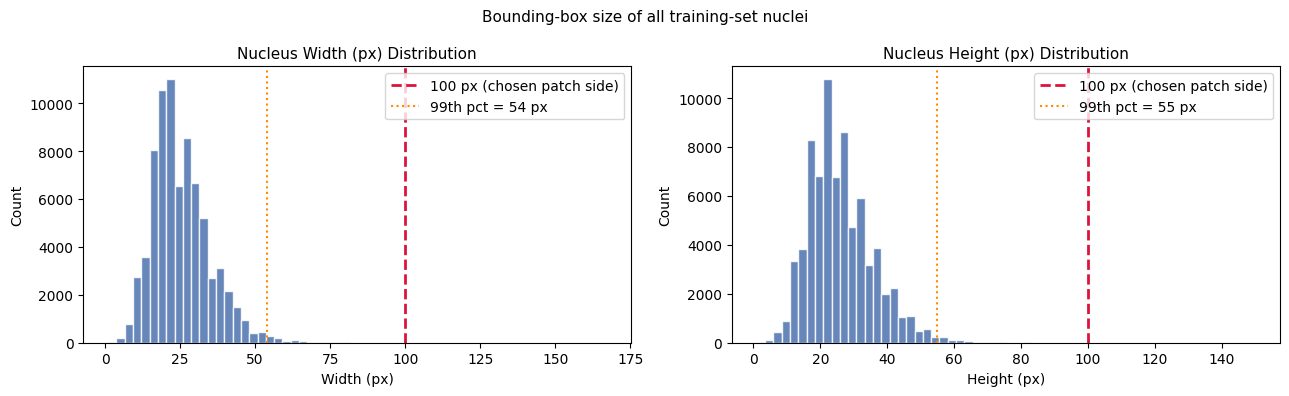

In [27]:
# Plotting width and height distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, vals, label in [(axes[0], widths, "Width (px)"), (axes[1], heights, "Height (px)")]:
    ax.hist(vals, bins=60, color="#4c72b0", edgecolor="white", alpha=0.85)
    ax.axvline(100, color="crimson", linewidth=2, linestyle="--", label="100 px (chosen patch side)")
    ax.axvline(np.percentile(vals, 99), color="darkorange", linewidth=1.5, linestyle=":", label=f"99th pct = {np.percentile(vals,99):.0f} px")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Nucleus {label} Distribution")
    ax.legend()

plt.suptitle("Bounding-box size of all training-set nuclei", fontsize=11)
plt.tight_layout()
plt.show()

In [28]:
#Verifying all test dataset patch size
sample_npys = sorted(TEST_SET_DIR.glob("*.npy"))

shapes, dtypes, ranges = [], [], []
for p in sample_npys:
    arr = np.load(p)
    shapes.append(arr.shape)
    dtypes.append(str(arr.dtype))
    ranges.append((arr.min(), arr.max()))

print(f"{'File':<90} {'Shape':<12} {'dtype':<8} {'min':>5} {'max':>5}")
print("-"*120)
for p, sh, dt, (mn, mx) in zip(sample_npys, shapes, dtypes, ranges):
    print(f"{p.name:<65} {str(sh):<15} {dt:<8} {mn:>5} {mx:>5}")

print(f"\nAll patches are {shapes[0]}")

File                                                                                       Shape        dtype      min   max
------------------------------------------------------------------------------------------------------------------------
test_set_metastatic_roi_013_nuclei_lymphocyte_9a29d664-f7b2-11f0-b0ff-2dd5e94cb1a9.npy (100, 100, 3)   uint8       19   255
test_set_metastatic_roi_013_nuclei_lymphocyte_9ab7f50c-f7b2-11f0-b0ff-2dd5e94cb1a9.npy (100, 100, 3)   uint8       24   255
test_set_metastatic_roi_013_nuclei_lymphocyte_9ad79bc8-f7b2-11f0-b0ff-2dd5e94cb1a9.npy (100, 100, 3)   uint8       18   255
test_set_metastatic_roi_013_nuclei_lymphocyte_9af5a9d8-f7b2-11f0-b0ff-2dd5e94cb1a9.npy (100, 100, 3)   uint8       22   255
test_set_metastatic_roi_013_nuclei_lymphocyte_9b7dccbe-f7b2-11f0-b0ff-2dd5e94cb1a9.npy (100, 100, 3)   uint8        0   255
test_set_metastatic_roi_013_nuclei_tumor_98cff1c2-f7b2-11f0-b0ff-2dd5e94cb1a9.npy (100, 100, 3)   uint8        0   255
test_set_metast


## 5. Colour Analysis per Class

In [29]:
# Per Class mean RGB
mean_rgb = {}

for cls in ORDERED_CLASSES:
    mask = y_names_train == cls
    patches_cls = X_train[mask]      
    if len(patches_cls) == 0:
        continue
    R = patches_cls[:, :, :, 0].astype(float)
    G = patches_cls[:, :, :, 1].astype(float)
    B = patches_cls[:, :, :, 2].astype(float)
    mean_rgb[cls] = (R.mean(), G.mean(), B.mean())
    print(f"  {cls:<28}  R={R.mean():5.1f}  G={G.mean():5.1f}  B={B.mean():5.1f}")

  nuclei_apoptosis              R=157.5  G= 95.0  B=170.8
  nuclei_endothelium            R=153.6  G=103.9  B=172.2
  nuclei_epithelium             R=132.4  G= 89.1  B=154.5
  nuclei_histiocyte             R=144.1  G= 99.4  B=166.9
  nuclei_lymphocyte             R=134.0  G= 87.9  B=160.6
  nuclei_melanophage            R=137.4  G= 92.1  B=143.8
  nuclei_neutrophil             R=169.3  G= 91.4  B=171.3
  nuclei_plasma_cell            R=140.7  G= 83.0  B=163.2
  nuclei_stroma                 R=157.5  G=105.2  B=172.8
  nuclei_tumor                  R=143.0  G= 93.3  B=165.5


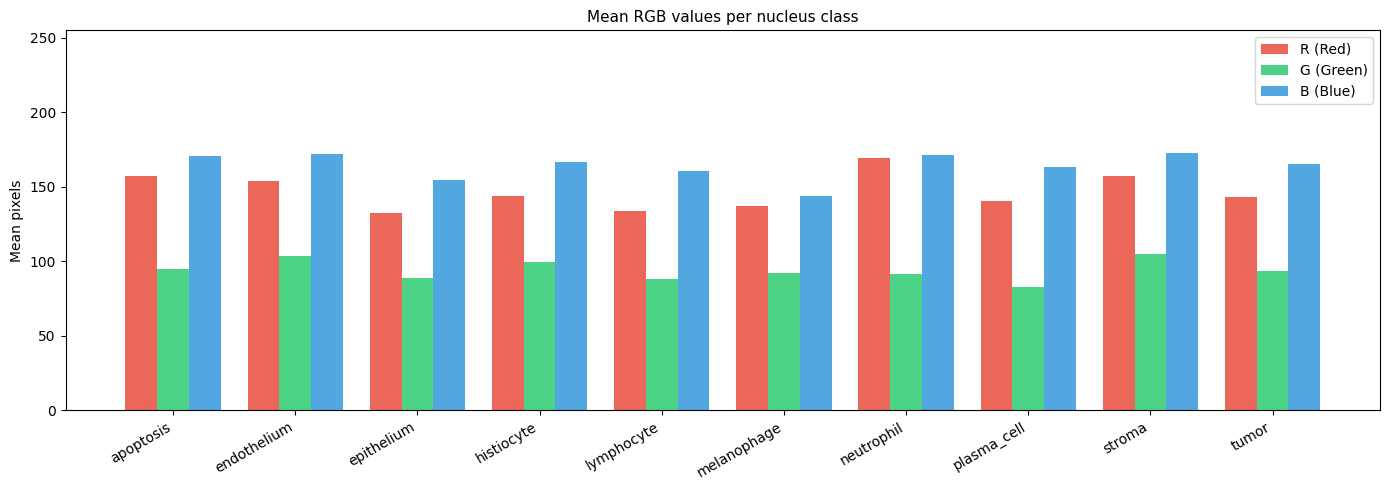

In [30]:
# Grouped bar chart of mean RGB classes

classes_list = [c for c in ORDERED_CLASSES if c in mean_rgb]
R_means = [mean_rgb[c][0] for c in classes_list]
G_means = [mean_rgb[c][1] for c in classes_list]
B_means = [mean_rgb[c][2] for c in classes_list]

x = np.arange(len(classes_list))
w = 0.26

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w,  R_means, w, label="R (Red)",  color="#e74c3c", alpha=0.85)
ax.bar(x,      G_means, w, label="G (Green)", color="#2ecc71", alpha=0.85)
ax.bar(x + w,  B_means, w, label="B (Blue)",  color="#3498db", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([c.replace("nuclei_", "") for c in classes_list],
                   rotation=30, ha="right")
ax.set_ylabel("Mean pixels")
ax.set_title("Mean RGB values per nucleus class")
ax.legend()
ax.set_ylim(0, 255)
plt.tight_layout()
plt.show()

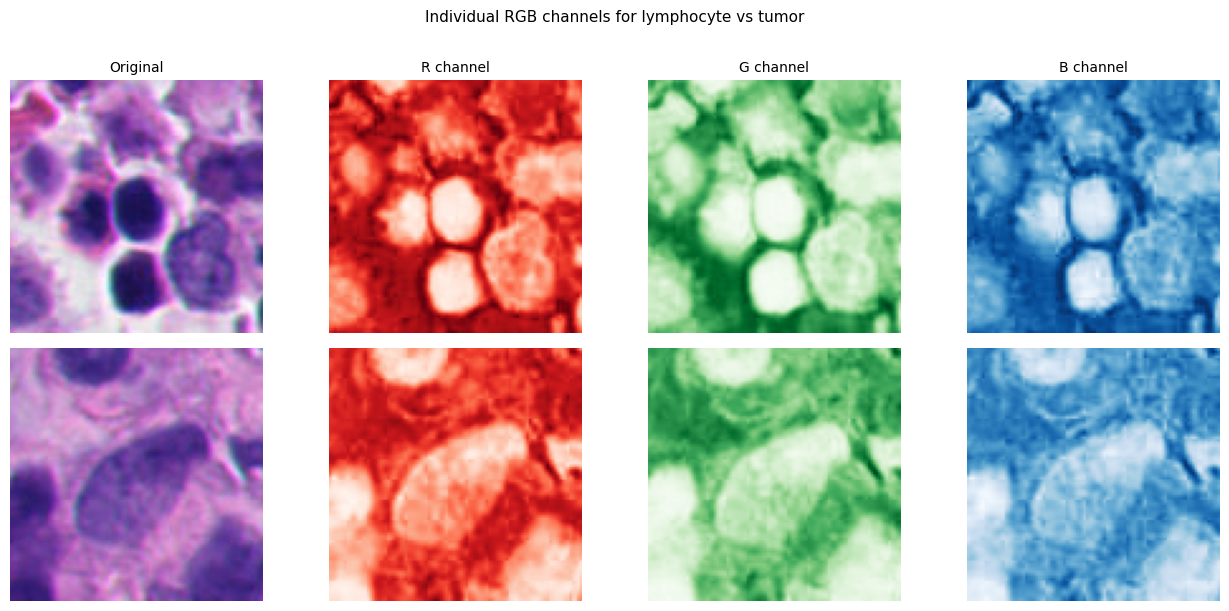

In [31]:
# Checking RGB channels separately for the two classes
# Picked blue for lymphocyte and pink for tumor
demo_classes = ["nuclei_lymphocyte", "nuclei_tumor"]

fig, axes = plt.subplots(len(demo_classes), 4, figsize=(13, 6))

for row, cls in enumerate(demo_classes):
    mask = y_names_train == cls
    sample_idx = np.where(mask)[0][0]
    patch = X_train[sample_idx]  

    # Use cv2.split to separate channels
    B_ch, G_ch, R_ch = cv2.split(patch) 
  
    R_ch = patch[:, :, 0]
    G_ch = patch[:, :, 1]
    B_ch = patch[:, :, 2]

    titles = ["Original", "R channel", "G channel", "B channel"]
    images = [patch, R_ch, G_ch, B_ch]
    cmaps  = [None, "Reds", "Greens", "Blues"]

    for col, (title, img, cmap) in enumerate(zip(titles, images, cmaps)):
        ax = axes[row, col]
        ax.imshow(img, cmap=cmap)
        ax.axis("off")
        if row == 0:
            ax.set_title(title, fontsize=10)
        if col == 0:
            ax.set_ylabel(cls.replace("nuclei_", ""), fontsize=9,
                         rotation=0, labelpad=60, va="center")

plt.suptitle("Individual RGB channels for lymphocyte vs tumor",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 6. Pixel Intensity Distributions

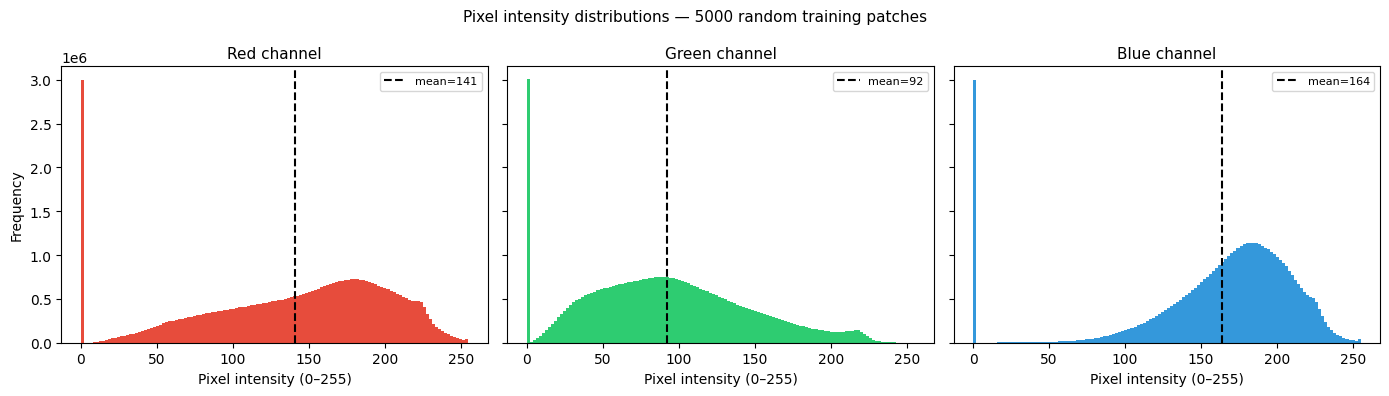

Red    mean=141.1  std=62.3  min=0  max=255
Green  mean=92.2  std=53.1  min=0  max=255
Blue   mean=163.7  std=53.6  min=0  max=255


In [32]:
# dataset pixel intensity histogram

N_SAMPLE = min(5000, len(X_train))
rng_idx   = np.random.choice(len(X_train), N_SAMPLE, replace=False)
subset    = X_train[rng_idx]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
channel_names = ["Red", "Green", "Blue"]
channel_colors = ["#e74c3c", "#2ecc71", "#3498db"]

for ch, (ax, name, col) in enumerate(zip(axes, channel_names, channel_colors)):
    vals = subset[:, :, :, ch].ravel()
    ax.hist(vals, bins=128, color=col, edgecolor="none")
    ax.axvline(vals.mean(), color="black", linewidth=1.5, linestyle="--", label=f"mean={vals.mean():.0f}")
    ax.set_xlabel("Pixel intensity (0–255)")
    ax.set_title(f"{name} channel")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frequency")
plt.suptitle(f"Pixel intensity distributions — {N_SAMPLE} random training patches", fontsize=11)
plt.tight_layout()
plt.show()

for ch, name in enumerate(channel_names):
    v = subset[:, :, :, ch].ravel()
    print(f"{name:5s}  mean={v.mean():.1f}  std={v.std():.1f}  min={v.min()}  max={v.max()}")

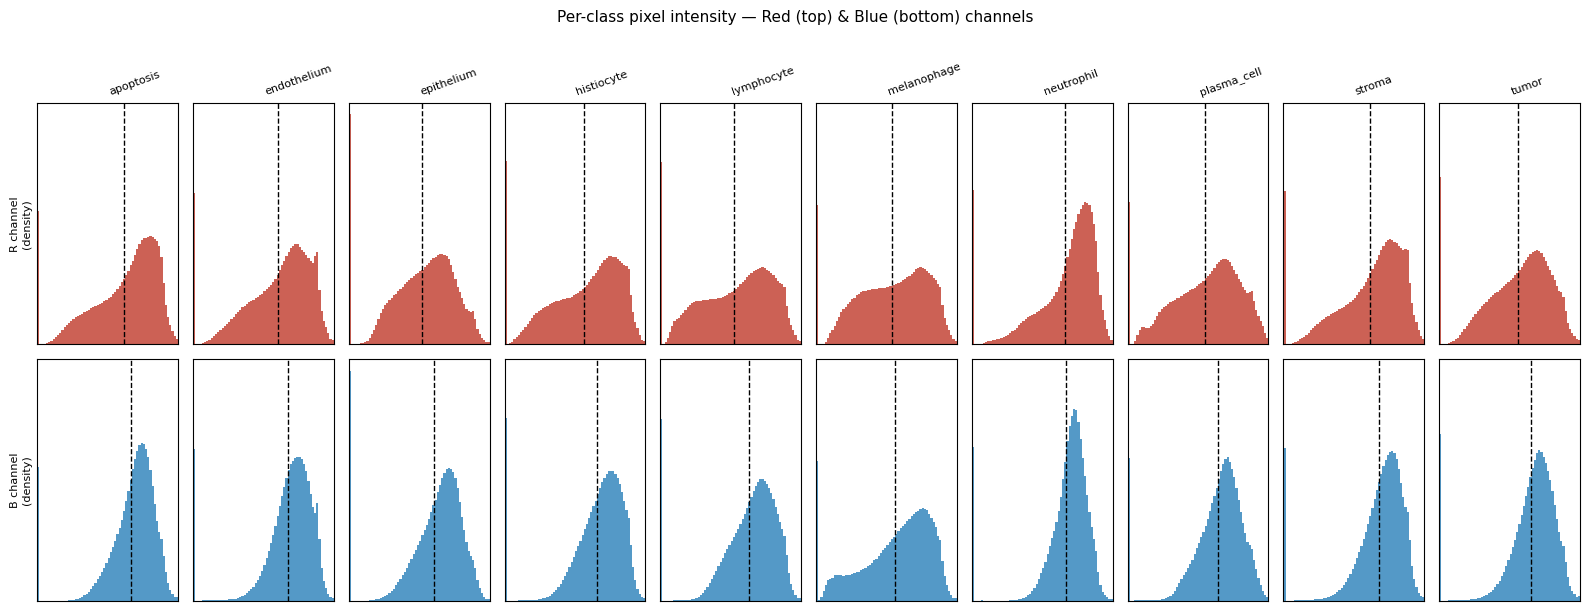

In [33]:
# ── 6b. Per-class intensity histograms for Red and Blue channels ──────────────
# These two channels are most discriminative in H&E staining.
fig, axes = plt.subplots(2, len(ORDERED_CLASSES),
                         figsize=(len(ORDERED_CLASSES) * 1.6, 6),
                         sharey="row")

for col, cls in enumerate(ORDERED_CLASSES):
    mask = y_names_train == cls
    patches_cls = X_train[mask]

    for row, (ch_idx, color, ch_name) in enumerate([
            (0, "#c0392b", "R"), (2, "#2980b9", "B")]):
        ax = axes[row, col]
        vals = patches_cls[:, :, :, ch_idx].ravel()
        ax.hist(vals, bins=64, color=color, alpha=0.8, edgecolor="none",
                density=True)
        ax.axvline(vals.mean(), color="black", linewidth=1, linestyle="--")
        ax.set_xlim(0, 255)
        if col == 0:
            ax.set_ylabel(f"{ch_name} channel\n(density)", fontsize=8)
        if row == 0:
            ax.set_title(cls.replace("nuclei_", ""), fontsize=8, rotation=20,
                        ha="left")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Per-class pixel intensity — Red (top) & Blue (bottom) channels",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 7. Class / Label Distribution across Splits


In [34]:
import json
from collections import Counter

# ── 7a. Load label arrays for all three splits ────────────────────────────────
y_names_val  = np.load(PREPARED_DIR / "y_names_validation.npy", allow_pickle=True)
y_names_test = np.load(PREPARED_DIR / "y_names_test.npy",       allow_pickle=True)

splits = {"Train": y_names_train, "Validation": y_names_val, "Test": y_names_test}

# Short display names (strip "nuclei_" prefix)
short = {c: c.replace("nuclei_", "") for c in ORDERED_CLASSES}

# Count per class per split
counts = {name: [Counter(arr)[cls] for cls in ORDERED_CLASSES]
          for name, arr in splits.items()}

print(f"{'Class':<20}  {'Train':>7}  {'Val':>7}  {'Test':>7}")
print("-" * 48)
for i, cls in enumerate(ORDERED_CLASSES):
    row = [counts[s][i] for s in splits]
    print(f"{short[cls]:<20}  {row[0]:>7,}  {row[1]:>7,}  {row[2]:>7,}")
print("-" * 48)
totals = [sum(counts[s]) for s in splits]
print(f"{'TOTAL':<20}  {totals[0]:>7,}  {totals[1]:>7,}  {totals[2]:>7,}")

Class                   Train      Val     Test
------------------------------------------------
apoptosis               1,375      348       81
endothelium             1,423      126      147
epithelium              1,599       92      520
histiocyte              5,823      887      458
lymphocyte             17,650    2,351    1,642
melanophage               602       16       77
neutrophil                290       60       16
plasma_cell               492       24        4
stroma                  3,025      492      339
tumor                  43,790    5,800    7,644
------------------------------------------------
TOTAL                  76,069   10,196   10,928


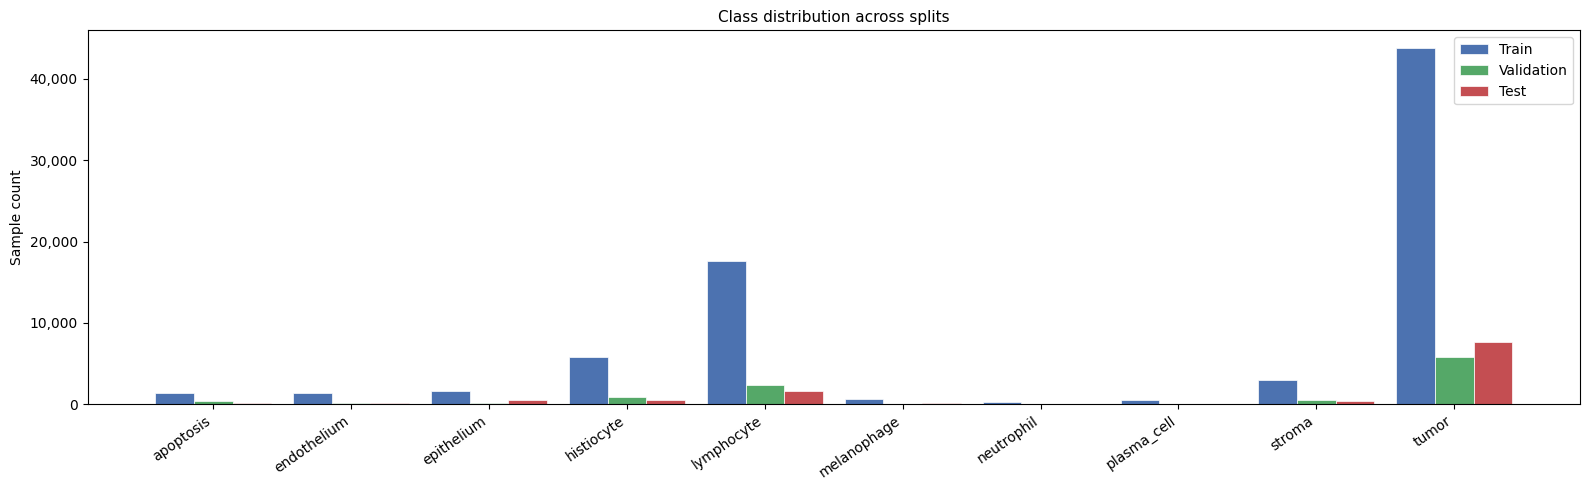

/var/folders/1m/9myllf0s1pn1dtpv5ycpddf80000gn/T/ipykernel_51134/2213125234.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(ORDERED_CLASSES))


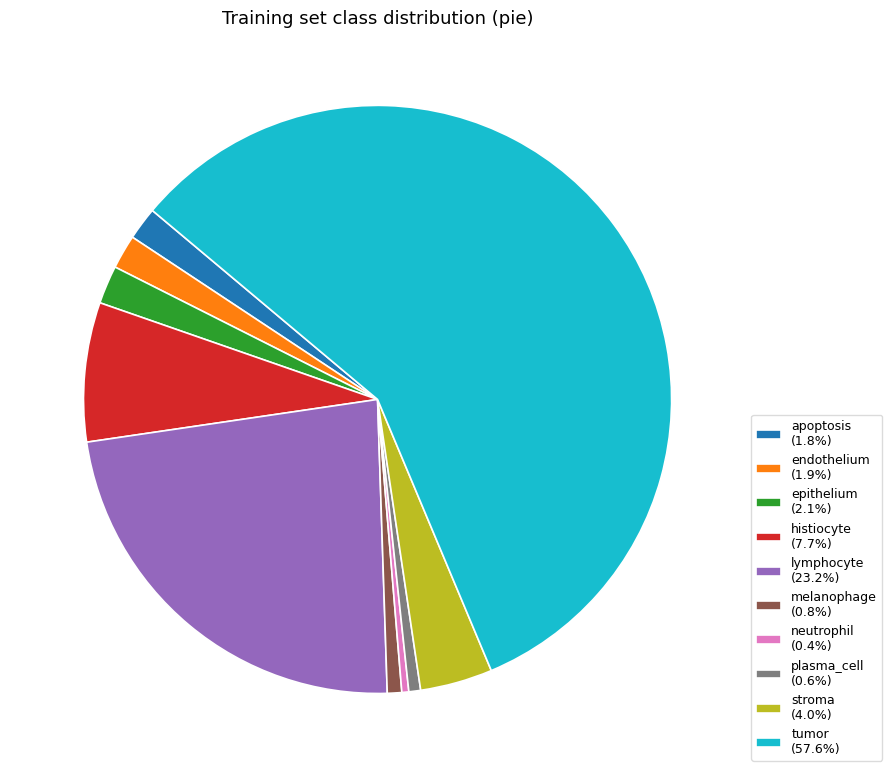


Key observation: nuclei_tumor and nuclei_stroma dominate; nuclei_plasma_cell and nuclei_melanophage are very rare.


In [35]:
# ── 7b. Grouped bar chart – count per class in each split ────────────────────
x      = np.arange(len(ORDERED_CLASSES))
width  = 0.28
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(16, 5))
for k, (sname, color) in enumerate(zip(splits, colors)):
    ax.bar(x + (k - 1) * width, counts[sname], width,
           label=sname, color=color, edgecolor="white", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([short[c] for c in ORDERED_CLASSES], rotation=35, ha="right", fontsize=10)
ax.set_ylabel("Sample count")
ax.set_title("Class distribution across splits")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.show()

# Define consistent class colors for downstream plots (pie + other class-wise charts).
palette = plt.cm.get_cmap("tab10", len(ORDERED_CLASSES))
CLASS_COLORS = {cls: palette(i) for i, cls in enumerate(ORDERED_CLASSES)}

# ── 7c. Pie chart – training split only ──────────────────────────────────────
train_counts = counts["Train"]
pie_colors   = [CLASS_COLORS.get(c, "#aaaaaa") for c in ORDERED_CLASSES]
labels_pct   = [f"{short[c]}\n({100*n/sum(train_counts):.1f}%)"
                for c, n in zip(ORDERED_CLASSES, train_counts)]

fig, ax = plt.subplots(figsize=(9, 9))
wedges, _ = ax.pie(train_counts, colors=pie_colors, startangle=140,
                   wedgeprops=dict(edgecolor="white", linewidth=1.2))
ax.legend(wedges, labels_pct, loc="lower left", bbox_to_anchor=(1, 0),
          fontsize=9, framealpha=0.7)
ax.set_title("Training set class distribution (pie)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nKey observation: nuclei_tumor and nuclei_stroma dominate; "
      "nuclei_plasma_cell and nuclei_melanophage are very rare.")


## 8. Image Preprocessing Preview

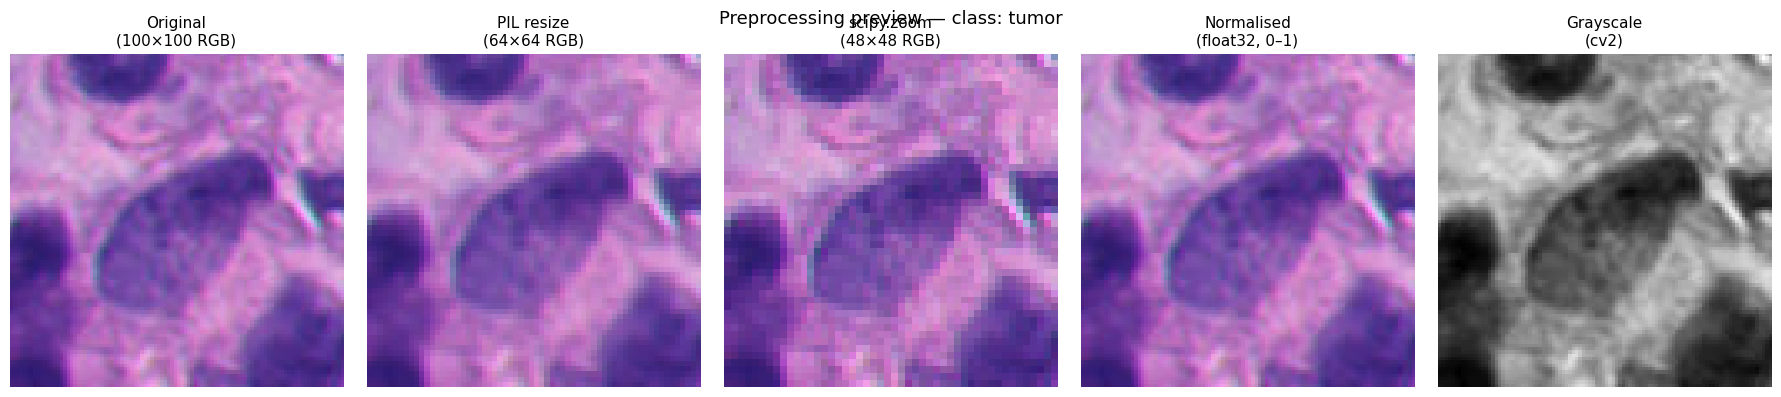

Original dtype/shape : uint8  (100, 100, 3)   range [22–255]
Normalised dtype     : float32  (100, 100, 3)  range [0.086–1.000]
Grayscale dtype      : uint8  (100, 100)


In [36]:
from scipy.ndimage import zoom as nd_zoom
from PIL import Image as PILImage

# Pick one patch per class for demonstration (first occurrence in training set)
demo_patches = {}
for cls in ORDERED_CLASSES:
    idx = np.where(y_names_train == cls)[0]
    if len(idx):
        demo_patches[cls] = X_train[idx[0]]

chosen_cls   = "nuclei_tumor"
patch_orig   = demo_patches[chosen_cls]           # (100, 100, 3) uint8

# ── 8a. Resize ────────────────────────────────────────────────────────────────
# PIL resize to 64×64
pil_img      = PILImage.fromarray(patch_orig)
patch_pil64  = np.array(pil_img.resize((64, 64), PILImage.BILINEAR))

# scipy.ndimage.zoom to 48×48
zoom_factor  = 48 / 100
patch_zoom48 = nd_zoom(patch_orig, (zoom_factor, zoom_factor, 1)).astype(np.uint8)

# ── 8b. Normalise (float32, 0–1) ─────────────────────────────────────────────
patch_norm = patch_orig.astype(np.float32) / 255.0

# ── 8c. Grayscale via cv2 ─────────────────────────────────────────────────────
patch_gray = cv2.cvtColor(patch_orig, cv2.COLOR_RGB2GRAY)   # (100, 100)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(patch_orig);         axes[0].set_title("Original\n(100×100 RGB)")
axes[1].imshow(patch_pil64);        axes[1].set_title("PIL resize\n(64×64 RGB)")
axes[2].imshow(patch_zoom48);       axes[2].set_title("scipy.zoom\n(48×48 RGB)")
axes[3].imshow(patch_norm);         axes[3].set_title("Normalised\n(float32, 0–1)")
axes[4].imshow(patch_gray, cmap="gray")
axes[4].set_title("Grayscale\n(cv2)")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"Preprocessing preview — class: {chosen_cls.replace('nuclei_', '')}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Original dtype/shape : {patch_orig.dtype}  {patch_orig.shape}   range [{patch_orig.min()}–{patch_orig.max()}]")
print(f"Normalised dtype     : {patch_norm.dtype}  {patch_norm.shape}  range [{patch_norm.min():.3f}–{patch_norm.max():.3f}]")
print(f"Grayscale dtype      : {patch_gray.dtype}  {patch_gray.shape}")

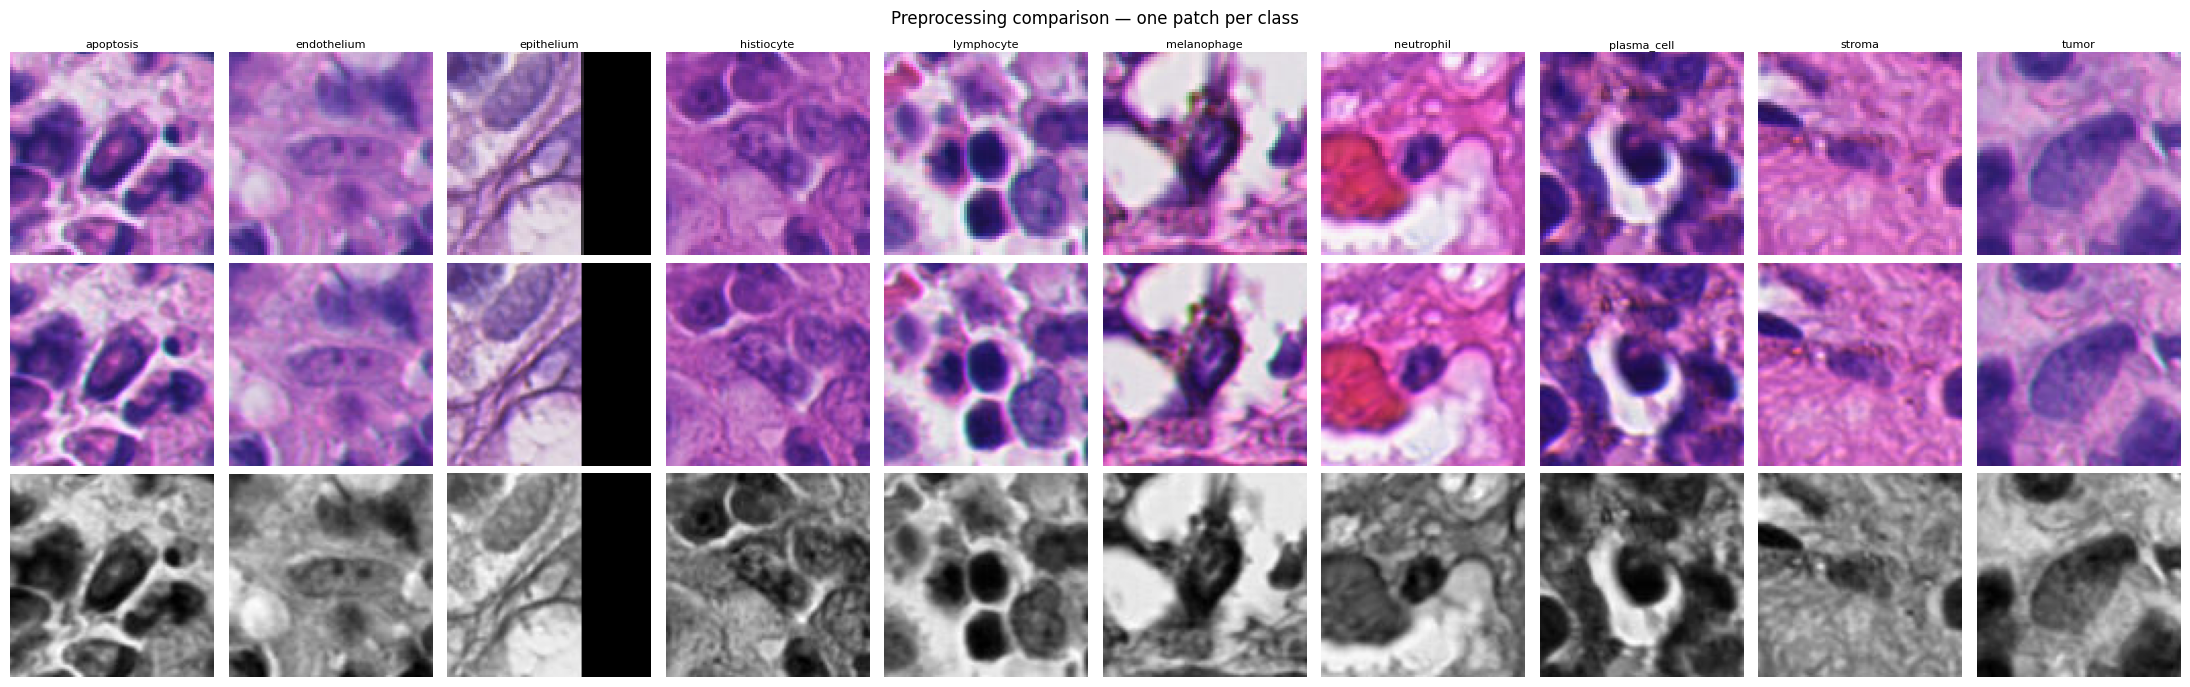

In [37]:
# ── 8d. Apply same preprocessing to one patch from each class ─────────────────
n_cls = len(ORDERED_CLASSES)
fig, axes = plt.subplots(3, n_cls, figsize=(2.2 * n_cls, 7))

for j, cls in enumerate(ORDERED_CLASSES):
    if cls not in demo_patches:
        for row in range(3):
            axes[row, j].axis("off")
        continue

    p     = demo_patches[cls]
    p_rgb = PILImage.fromarray(p).resize((64, 64), PILImage.BILINEAR)
    p_rgb = np.array(p_rgb)
    p_nrm = p.astype(np.float32) / 255.0
    p_gry = cv2.cvtColor(p, cv2.COLOR_RGB2GRAY)

    axes[0, j].imshow(p_rgb);              axes[0, j].axis("off")
    axes[1, j].imshow(p_nrm);              axes[1, j].axis("off")
    axes[2, j].imshow(p_gry, cmap="gray"); axes[2, j].axis("off")

    axes[0, j].set_title(cls.replace("nuclei_", ""), fontsize=8, pad=3)

axes[0, 0].set_ylabel("PIL 64×64",  fontsize=9, labelpad=4)
axes[1, 0].set_ylabel("Normalised", fontsize=9, labelpad=4)
axes[2, 0].set_ylabel("Grayscale",  fontsize=9, labelpad=4)

fig.suptitle("Preprocessing comparison — one patch per class", fontsize=12)
plt.tight_layout()
plt.show()